# 02 · Material classification (milestone M2)

**Interim**: four classes from Sentinel-2 (vegetation / dark / bright / bare soil), per the fallback in CLAUDE.md. Replaced by the EnMAP classifier when data access is granted. Validate by spot-checking 20 roofs against high-resolution imagery.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from coolcairo.config import load_config, geobox_for
cfg = load_config()

In [2]:
from coolcairo.pipeline import load_sentinel2
from coolcairo.classify import classify_sentinel2, Material
s2 = load_sentinel2(cfg)
material = classify_sentinel2(cfg, s2)
shares = material.to_series().value_counts(normalize=True).rename(lambda c: Material(c).name)
shares

material
SOIL          0.488579
BRIGHT        0.348668
DARK          0.099462
VEGETATION    0.063290
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Interim material classes: nodata / vegetation / dark / bright / soil')

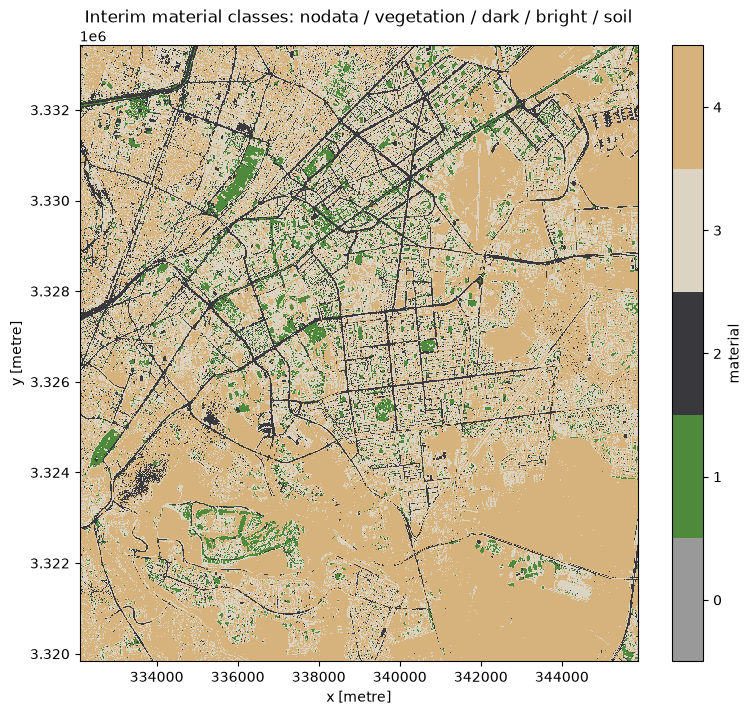

In [3]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#999999', '#4f8a3c', '#38383d', '#dbd4c2', '#d6b37d'])
material.plot(cmap=cmap, vmin=-0.5, vmax=4.5, figsize=(9, 8))
plt.title('Interim material classes: nodata / vegetation / dark / bright / soil')

## Bare soil threshold (`bsi_soil_min`)
Brightness cannot separate pale roofs from desert soil. The Bare Soil Index threshold is chosen as the best single split between pixels inside OSM footprints (roofs) and open ground more than 300 m from any footprint. Re-running this cell reproduces the value in `config/aoi.yaml`.

In [4]:
from scipy.ndimage import distance_transform_edt
from coolcairo.buildings import footprint_mask
from coolcairo.classify import soil_threshold
from coolcairo.pipeline import load_buildings, FINE_RESOLUTION
roof = footprint_mask(load_buildings(cfg), geobox_for(cfg, 'model_aoi', FINE_RESOLUTION)).values.astype(bool)
open_ground = distance_transform_edt(~roof) * FINE_RESOLUTION > 300
threshold, accuracy = soil_threshold(s2, roof, open_ground, cfg['s2_classification']['ndvi_vegetation'])
print(f'BSI threshold {threshold:.3f}, balanced accuracy {accuracy:.2f}; config uses {cfg["s2_classification"]["bsi_soil_min"]}')

BSI threshold 0.137, balanced accuracy 0.75; config uses 0.137


## Spot-check sheet (M2)
20 points, 5 per class, inside the display district and only in uniform 30 m patches (so a small offset cannot land on another class). A person fills in `docs/m2_spot_check.xlsx` from Google Maps satellite view; the agreement figure goes in the report. Fixed seed, so re-running produces the same points.

In [5]:
from coolcairo import validation
from coolcairo.config import REPO_ROOT
points = validation.sample_points(cfg, material)
sheet = REPO_ROOT / 'docs' / 'm2_spot_check.xlsx'
if not sheet.exists():  # never overwrite a sheet someone has started filling in
    validation.write_sheet(points, sheet)
points[['lat', 'lon', 'predicted_label']].round(5)

,lat,lon,predicted_label
0,30.05022,31.33771,Vegetation
1,30.06458,31.33809,Bare soil / sand
2,30.06009,31.33329,Bare soil / sand
3,30.05967,31.33537,Vegetation
4,30.05385,31.33899,Dark surface
5,30.04983,31.32776,Dark surface
6,30.05203,31.33093,Bright surface
7,30.06497,31.34057,Vegetation
8,30.06559,31.33952,Bare soil / sand
9,30.06811,31.34612,Bare soil / sand


In [6]:
# After the sheet is filled in: agreement per point and overall.
results = validation.read_results(sheet)
print(f"Agreement: {results.match.mean():.0%} of {int(results.match.notna().sum())} checked points")
results

Agreement: 89% of 18 checked points


,point,predicted,observed,match
0,1,Vegetation,Vegetation,1.0
1,2,Bare soil / sand,Bare soil / sand,1.0
2,3,Bare soil / sand,Dark surface,0.0
3,4,Vegetation,Vegetation,1.0
4,5,Dark surface,Dark surface,1.0
5,6,Dark surface,Dark surface,1.0
6,7,Bright surface,Unsure / can't tell,NaN
7,8,Vegetation,Vegetation,1.0
8,9,Bare soil / sand,Bright surface,0.0
9,10,Bare soil / sand,Bare soil / sand,1.0
